In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import pearsonr
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn import preprocessing
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

## Data Selection

In [2]:
# Project path
DATA_PATH = Path("../data/raw/CarsData.csv")


cars = pd.read_csv(DATA_PATH)
print(f"The dataset has {cars.shape[0]} rows and {cars.shape[1]} columns.")


The dataset has 97712 rows and 10 columns.


In [3]:
cars.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize', 'Manufacturer'],
      dtype='str')

In [4]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 97712 entries, 0 to 97711
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         97712 non-null  str    
 1   year          97712 non-null  int64  
 2   price         97712 non-null  int64  
 3   transmission  97712 non-null  str    
 4   mileage       97712 non-null  int64  
 5   fuelType      97712 non-null  str    
 6   tax           97712 non-null  int64  
 7   mpg           97712 non-null  float64
 8   engineSize    97712 non-null  float64
 9   Manufacturer  97712 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 7.5 MB


In [5]:
cars.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Manufacturer
0,I10,2017,7495,Manual,11630,Petrol,145,60.10,1.00,hyundi
1,Polo,2017,10989,Manual,9200,Petrol,145,58.90,1.00,volkswagen
2,2 Series,2019,27990,Semi-Auto,1614,Diesel,145,49.60,2.00,BMW
3,Yeti Outdoor,2017,12495,Manual,30960,Diesel,150,62.80,2.00,skoda
4,Fiesta,2017,7999,Manual,19353,Petrol,125,54.30,1.20,ford


In [6]:
cars.describe()

,year,price,mileage,tax,mpg,engineSize
count,97712.00,97712.00,97712.00,97712.00,97712.00,97712.00
mean,2017.07,16773.49,23219.48,120.14,55.21,1.66
std,2.12,9868.55,21060.88,63.36,16.18,0.56
min,1970.00,450.00,1.00,0.00,0.30,0.00
25%,2016.00,9999.00,7673.00,125.00,47.10,1.20
50%,2017.00,14470.00,17682.50,145.00,54.30,1.60
75%,2019.00,20750.00,32500.00,145.00,62.80,2.00
max,2024.00,159999.00,323000.00,580.00,470.80,6.60


## Data Cleaning

In [7]:
# Check for missing values
missing_values = cars.isnull().sum()
missing_values

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Manufacturer    0
dtype: int64

In [8]:
# Check for duplicate rows
duplicate_count = cars.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


 No duplicates exist, so no need to remove 

In [9]:
# Standardise column names
cars = cars.rename(columns={
    "fuelType": "fuel_type",
    "engineSize": "engine_size",
    "Manufacturer": "manufacturer"
})

cars.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuel_type', 'tax',
       'mpg', 'engine_size', 'manufacturer'],
      dtype='str')

In [10]:
for col in ["transmission", "fuel_type", "manufacturer"]:
    print(f"\n{col}:")
    print(cars[col].value_counts())


transmission:
transmission
Manual       55502
Semi-Auto    22296
Automatic    19905
Other            9
Name: count, dtype: int64

fuel_type:
fuel_type
Petrol      53982
Diesel      40419
Hybrid       3059
Other         246
Electric        6
Name: count, dtype: int64

manufacturer:
manufacturer
ford          17811
volkswagen    14893
vauxhall      13258
merc          12860
BMW           10664
Audi          10565
toyota         6699
skoda          6188
hyundi         4774
Name: count, dtype: int64


In [11]:
# Fix spelling 
cars["manufacturer"] = cars["manufacturer"].str.strip().str.title()

cars["manufacturer"] = cars["manufacturer"].replace({
    "Hyundi": "Hyundai",
    "Bmw": "BMW"
})

cars["manufacturer"].value_counts()

manufacturer
Ford          17811
Volkswagen    14893
Vauxhall      13258
Merc          12860
BMW           10664
Audi          10565
Toyota         6699
Skoda          6188
Hyundai        4774
Name: count, dtype: int64

The manufacturer column was cleaned to make the formatting consistent. The value `hyundi` was corrected to `Hyundai`, and `BMW` was kept in uppercase.

In [12]:
CURRENT_YEAR = 2026

cars["car_age"] = CURRENT_YEAR - cars["year"]

cars[["year", "car_age"]].head()

,year,car_age
0,2017,9
1,2017,9
2,2019,7
3,2017,9
4,2017,9


A new `car_age` column was created because age is easier to interpret than model year when comparing cars.

In [13]:
# Check for missing columns
numeric_columns = ["year", "price", "mileage", "tax", "mpg", "engine_size", "car_age"]

cars[numeric_columns].describe()

,year,price,mileage,tax,mpg,engine_size,car_age
count,97712.00,97712.00,97712.00,97712.00,97712.00,97712.00,97712.00
mean,2017.07,16773.49,23219.48,120.14,55.21,1.66,8.93
std,2.12,9868.55,21060.88,63.36,16.18,0.56,2.12
min,1970.00,450.00,1.00,0.00,0.30,0.00,2.00
25%,2016.00,9999.00,7673.00,125.00,47.10,1.20,7.00
50%,2017.00,14470.00,17682.50,145.00,54.30,1.60,9.00
75%,2019.00,20750.00,32500.00,145.00,62.80,2.00,10.00
max,2024.00,159999.00,323000.00,580.00,470.80,6.60,56.00


In [14]:
print("Cars with price <= 0:", len(cars[cars["price"] <= 0]))
print("Cars with mileage < 0:", len(cars[cars["mileage"] < 0]))
print("Cars with mpg <= 0:", len(cars[cars["mpg"] <= 0]))
print("Cars with engine size <= 0:", len(cars[cars["engine_size"] <= 0]))
print("Cars with car age < 0:", len(cars[cars["car_age"] < 0]))

Cars with price <= 0: 0
Cars with mileage < 0: 0
Cars with mpg <= 0: 0
Cars with engine size <= 0: 268
Cars with car age < 0: 0


Cars with engine size 0 does not make sense, lets investigate

In [15]:
cars[cars["engine_size"] == 0]["fuel_type"].value_counts()

fuel_type
Petrol      158
Diesel       69
Hybrid       38
Electric      2
Other         1
Name: count, dtype: int64

Electric cars engine_size = 0 is ok beacuse they dont use the conventional engine, but in data, there are some electric cars with engine_size.
<br>To avoid unfair comparisons, remove engine_size

In [16]:
# Check for outliers
cars[["price", "mileage", "tax", "mpg", "car_age"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

,price,mileage,tax,mpg,car_age
count,97712.00,97712.00,97712.00,97712.00,97712.00
mean,16773.49,23219.48,120.14,55.21,8.93
std,9868.55,21060.88,63.36,16.18,2.12
min,450.00,1.00,0.00,0.30,2.00
1%,3995.00,11.00,0.00,29.70,6.00
5%,6495.00,1026.00,0.00,35.80,7.00
25%,9999.00,7673.00,125.00,47.10,7.00
50%,14470.00,17682.50,145.00,54.30,9.00
75%,20750.00,32500.00,145.00,62.80,10.00
95%,34280.00,64800.00,200.00,74.30,13.00


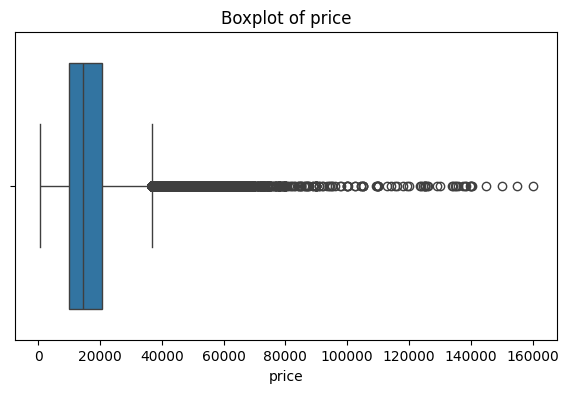

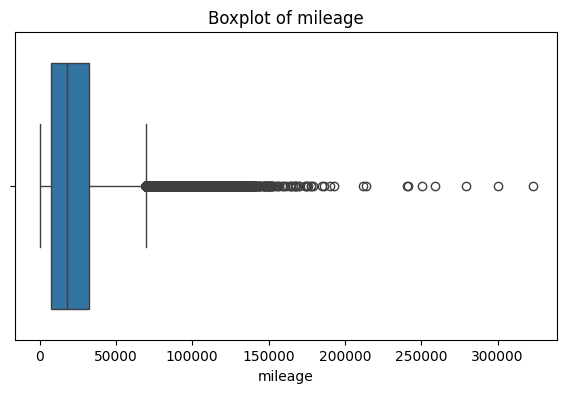

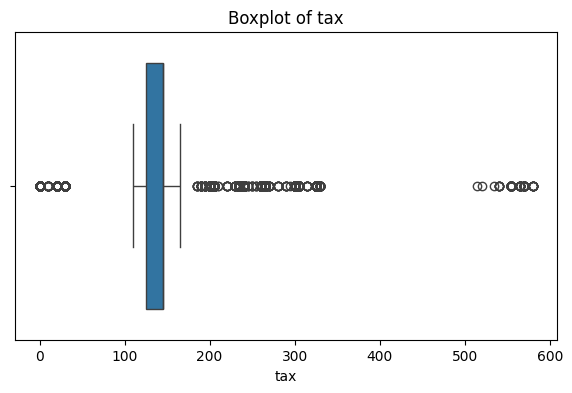

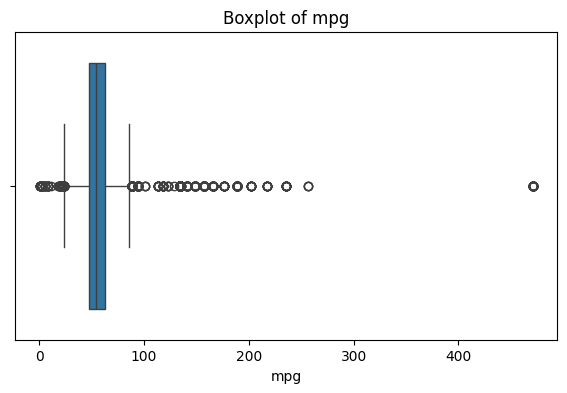

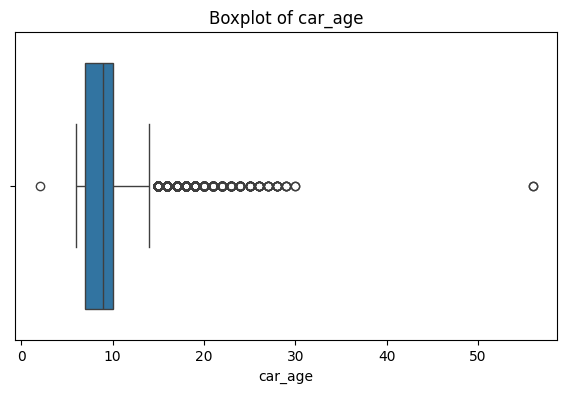

In [17]:
# Boxplots to visually check for outliers
outlier_columns = ["price", "mileage", "tax", "mpg", "car_age"]

for col in outlier_columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=cars[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

The `price` column has some very high values, with the 99th percentile at about 52,447 while the maximum price is 159,999. This suggests that a small number of cars are much more expensive than the majority of the dataset.

The `mileage` column also contains outliers. Most cars are below about 95,434 miles at the 99th percentile, but the maximum mileage is 323,000 miles. This shows that some cars have much higher mileage than normal.

The `mpg` column has a maximum value of 470.8, which is much higher than the 99th percentile value of 85.6. This may be caused by electric or hybrid vehicles, or unusual records in the dataset. The `car_age` column also contains a few older vehicles, with the maximum age being 56 years, while 99% of cars are 16 years old or younger.

These outliers were not removed immediately because they may represent real cars, such as luxury cars, high-mileage cars, electric/hybrid cars, or classic vehicles. However, they will need to be considered later when choosing a normalisation method, because extreme values can affect the final composite index.

In [18]:
outlier_columns = ["price", "mileage", "tax", "mpg", "car_age"]

for col in outlier_columns:
    lower = cars[col].quantile(0.01)
    upper = cars[col].quantile(0.99)
    
    below_lower = (cars[col] < lower).sum()
    above_upper = (cars[col] > upper).sum()
    
    print(f"{col}")
    print(f"Lower limit (1%): {lower}")
    print(f"Upper limit (99%): {upper}")
    print(f"Values below lower limit: {below_lower}")
    print(f"Values above upper limit: {above_upper}")
    print()

price
Lower limit (1%): 3995.0
Upper limit (99%): 52446.919999999984
Values below lower limit: 971
Values above upper limit: 978

mileage
Lower limit (1%): 11.0
Upper limit (99%): 95433.80999999998
Values below lower limit: 972
Values above upper limit: 978

tax
Lower limit (1%): 0.0
Upper limit (99%): 265.0
Values below lower limit: 0
Values above upper limit: 882

mpg
Lower limit (1%): 29.7
Upper limit (99%): 85.6
Values below lower limit: 922
Values above upper limit: 906

car_age
Lower limit (1%): 6.0
Upper limit (99%): 16.0
Values below lower limit: 1
Values above upper limit: 962



The outliers were not removed immediately because they may still represent real vehicles. However, they were noted because extreme values can affect the normalisation stage and may influence the final composite index.

## Data Label Encoding

In [19]:
# Get list of categorical variables
categorical_columns = cars.select_dtypes(include=["object", "string"]).columns

categorical_columns


Index(['model', 'transmission', 'fuel_type', 'manufacturer'], dtype='str')

In [20]:
# Create a summary of fuel types using average MPG and tax
fuel_summary = cars.groupby("fuel_type")[["mpg", "tax"]].mean()

fuel_summary


,mpg,tax
fuel_type,,
Diesel,58.25,114.45
Electric,297.07,22.50
Hybrid,88.98,71.90
Other,85.76,103.64
Petrol,50.85,127.22


In [21]:
# Function for normalising where higher values are better
def normalise(series):
    return (series - series.min()) / (series.max() - series.min())

# Function for normalising where lower values are better
def reverse_normalise(series):
    return 1 - ((series - series.min()) / (series.max() - series.min()))

# Higher MPG is better
fuel_summary["mpg_score"] = normalise(fuel_summary["mpg"])

# Lower tax is better
fuel_summary["tax_score"] = reverse_normalise(fuel_summary["tax"])

# Combine into fuel type score
fuel_summary["fuel_type_score"] = (
    fuel_summary["mpg_score"] * 0.7 +
    fuel_summary["tax_score"] * 0.3
)

fuel_summary

,mpg,tax,mpg_score,tax_score,fuel_type_score
fuel_type,,,,,
Diesel,58.25,114.45,0.03,0.12,0.06
Electric,297.07,22.50,1.00,1.00,1.00
Hybrid,88.98,71.90,0.15,0.53,0.27
Other,85.76,103.64,0.14,0.23,0.17
Petrol,50.85,127.22,0.00,0.00,0.00


In [22]:
fuel_score_map = fuel_summary["fuel_type_score"].to_dict()

cars["fuel_type_score"] = cars["fuel_type"].map(fuel_score_map)

cars[["fuel_type", "fuel_type_score"]].drop_duplicates().sort_values("fuel_type_score", ascending=False)

,fuel_type,fuel_type_score
12403,Electric,1.00
5,Hybrid,0.27
445,Other,0.17
2,Diesel,0.06
0,Petrol,0.00


In [23]:
transmission_encoded = pd.get_dummies(
    cars["transmission"],
    prefix="transmission",
    drop_first=False,
    dtype=int
)

cars_multi = cars[[
    "price",
    "mileage",
    "tax",
    "mpg",
    "car_age",
    "fuel_type_score"
]].copy()

cars_multi = pd.concat([cars_multi, transmission_encoded], axis=1)

cars_multi.head()

,price,mileage,tax,mpg,car_age,fuel_type_score,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto
0,7495,11630,145,60.10,9,0.00,0,1,0,0
1,10989,9200,145,58.90,9,0.00,0,1,0,0
2,27990,1614,145,49.60,7,0.06,0,0,0,1
3,12495,30960,150,62.80,9,0.06,0,1,0,0
4,7999,19353,125,54.30,9,0.00,0,1,0,0


## Multivariate Analysis


In [24]:
# Select variables for multivariate analysis
cars_multi = cars[[
    "price",
    "mileage",
    "tax",
    "mpg",
    "car_age",
    "fuel_type_score"
]].copy()

# Add the one-hot encoded transmission variables
cars_multi = pd.concat([cars_multi, transmission_encoded], axis=1)


In [25]:
display(cars_multi.head())

cars_multi.info()

display(cars_multi.describe())

,price,mileage,tax,mpg,car_age,fuel_type_score,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto
0,7495,11630,145,60.10,9,0.00,0,1,0,0
1,10989,9200,145,58.90,9,0.00,0,1,0,0
2,27990,1614,145,49.60,7,0.06,0,0,0,1
3,12495,30960,150,62.80,9,0.06,0,1,0,0
4,7999,19353,125,54.30,9,0.00,0,1,0,0


<class 'pandas.DataFrame'>
RangeIndex: 97712 entries, 0 to 97711
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   price                   97712 non-null  int64  
 1   mileage                 97712 non-null  int64  
 2   tax                     97712 non-null  int64  
 3   mpg                     97712 non-null  float64
 4   car_age                 97712 non-null  int64  
 5   fuel_type_score         97712 non-null  float64
 6   transmission_Automatic  97712 non-null  int64  
 7   transmission_Manual     97712 non-null  int64  
 8   transmission_Other      97712 non-null  int64  
 9   transmission_Semi-Auto  97712 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 7.5 MB


,price,mileage,tax,mpg,car_age,fuel_type_score,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto
count,97712.00,97712.00,97712.00,97712.00,97712.00,97712.00,97712.00,97712.00,97712.00,97712.00
mean,16773.49,23219.48,120.14,55.21,8.93,0.03,0.20,0.57,0.00,0.23
std,9868.55,21060.88,63.36,16.18,2.12,0.05,0.40,0.50,0.01,0.42
min,450.00,1.00,0.00,0.30,2.00,0.00,0.00,0.00,0.00,0.00
25%,9999.00,7673.00,125.00,47.10,7.00,0.00,0.00,0.00,0.00,0.00
50%,14470.00,17682.50,145.00,54.30,9.00,0.00,0.00,1.00,0.00,0.00
75%,20750.00,32500.00,145.00,62.80,10.00,0.06,0.00,1.00,0.00,0.00
max,159999.00,323000.00,580.00,470.80,56.00,1.00,1.00,1.00,1.00,1.00


### Checking Correlation

In [26]:
predictor_variable = ["price"]

response_variables = [
    "mileage",
    "tax",
    "mpg",
    "car_age",
    "fuel_type_score",
    "transmission_Automatic",
    "transmission_Manual",
    "transmission_Other",
    "transmission_Semi-Auto"
]

for predictor_var in predictor_variable:
    for response_var in response_variables:
        corr_coef, p_value = pearsonr(cars_multi[predictor_var], cars_multi[response_var])
        print(f"Pearson correlation coefficient between '{predictor_var}' and '{response_var}': {corr_coef:.2f}")
        print()

Pearson correlation coefficient between 'price' and 'mileage': -0.42

Pearson correlation coefficient between 'price' and 'tax': 0.31

Pearson correlation coefficient between 'price' and 'mpg': -0.30

Pearson correlation coefficient between 'price' and 'car_age': -0.49

Pearson correlation coefficient between 'price' and 'fuel_type_score': 0.16

Pearson correlation coefficient between 'price' and 'transmission_Automatic': 0.24

Pearson correlation coefficient between 'price' and 'transmission_Manual': -0.55

Pearson correlation coefficient between 'price' and 'transmission_Other': -0.00

Pearson correlation coefficient between 'price' and 'transmission_Semi-Auto': 0.41



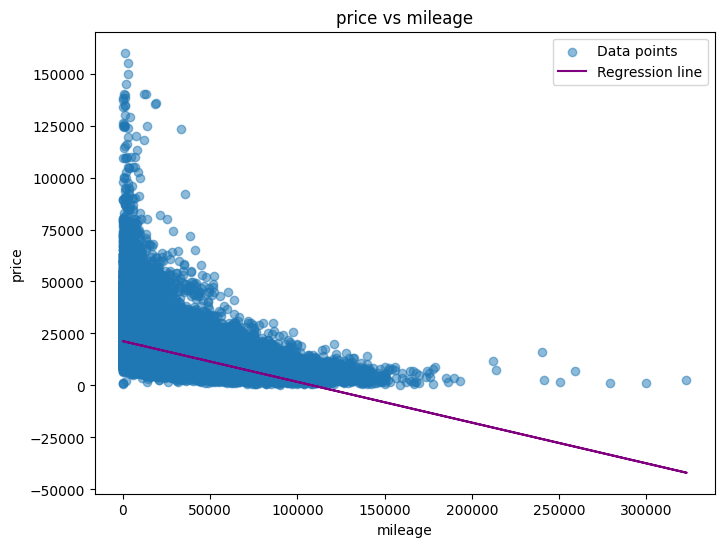

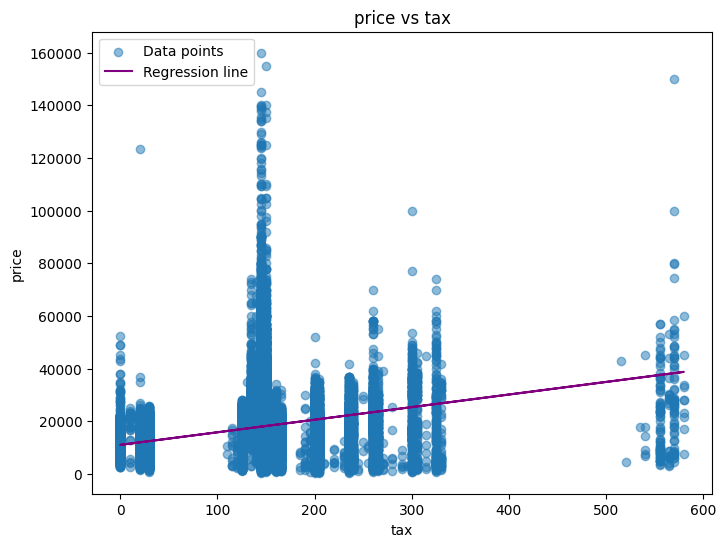

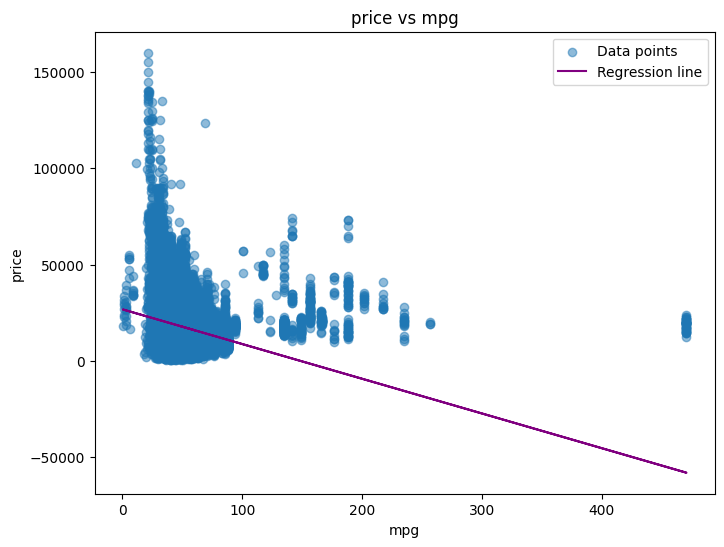

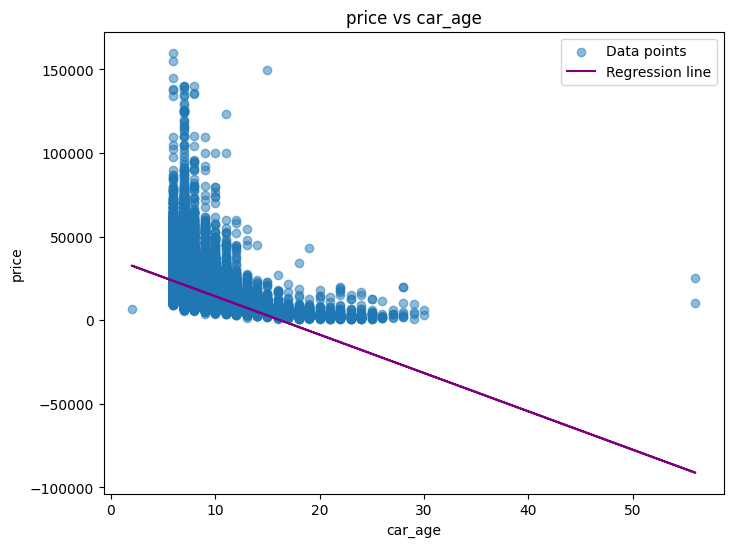

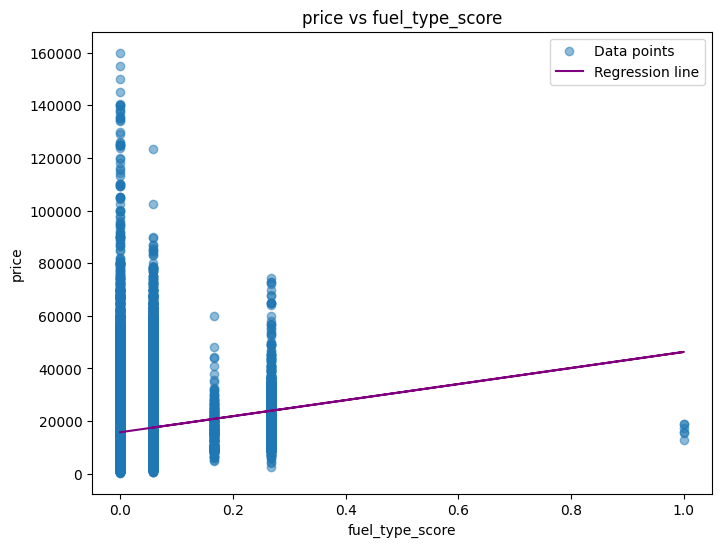

In [27]:
# Visualising the relationship between price and the other variables

predictor_var = "price"

response_variables = [
    "mileage",
    "tax",
    "mpg",
    "car_age",
    "fuel_type_score"
]

for response_var in response_variables:
    plt.figure(figsize=(8, 6))
    
    # Scatterplot
    plt.scatter(
        cars_multi[response_var],
        cars_multi[predictor_var],
        alpha=0.5,
        label="Data points"
    )
    
    plt.title(f"{predictor_var} vs {response_var}")
    plt.xlabel(response_var)
    plt.ylabel(predictor_var)
    
    # Fit a linear regression line
    m, b = np.polyfit(cars_multi[response_var], cars_multi[predictor_var], 1)
    plt.plot(
        cars_multi[response_var],
        m * cars_multi[response_var] + b,
        color="purple",
        label="Regression line"
    )
    
    plt.legend()
    plt.show()

In [28]:
# Average price by transmission type
transmission_price = cars.groupby("transmission")["price"].mean().sort_values(ascending=False)

transmission_price

transmission
Semi-Auto   24235.21
Automatic   21512.20
Other       16219.11
Manual      12076.62
Name: price, dtype: float64

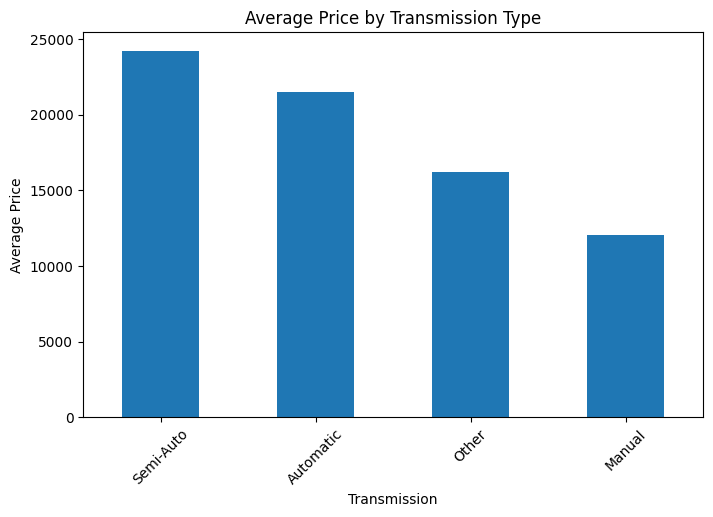

In [29]:
plt.figure(figsize=(8, 5))
transmission_price.plot(kind="bar")
plt.xlabel("Transmission")
plt.ylabel("Average Price")
plt.title("Average Price by Transmission Type")
plt.xticks(rotation=45)
plt.show()

| Variable compared with `price` | Pearson correlation | Interpretation |
|---|---:|---|
| `mileage` | -0.42 | Moderate negative relationship. Higher mileage is linked with lower price. |
| `tax` | 0.31 | Weak positive relationship. Higher tax cars tend to have higher prices. |
| `mpg` | -0.30 | Weak negative relationship. Higher MPG cars tend to have slightly lower prices. |
| `car_age` | -0.49 | Moderate negative relationship. Older cars tend to have lower prices. |
| `fuel_type_score` | 0.16 | Very weak positive relationship. Fuel type score has little relationship with price. |
| `transmission_Automatic` | 0.24 | Weak positive relationship. Automatic cars tend to be slightly more expensive. |
| `transmission_Manual` | -0.55 | Moderate negative relationship. Manual cars tend to be cheaper. |
| `transmission_Other` | -0.00 | No clear relationship with price. |
| `transmission_Semi-Auto` | 0.41 | Moderate positive relationship. Semi-auto cars tend to be more expensive. |

The scatterplots show that `mileage` and `car_age` both have a negative relationship with `price`. This means that cars with higher mileage or older age tend to have lower prices. This is expected because older and more heavily used cars are usually less valuable.

The relationship between `tax` and `price` is positive, meaning that higher-tax cars tend to have higher prices. This may be because more expensive cars are often larger or higher-spec vehicles.

The relationship between `mpg` and `price` is negative in this dataset. This may be because many high-MPG cars are smaller or cheaper vehicles, while more expensive vehicles may have lower fuel efficiency. The `fuel_type_score` has only a weak positive relationship with price.

The bar chart for transmission type shows that semi-automatic and automatic cars have higher average prices than manual cars. This suggests that transmission type may be related to car price.

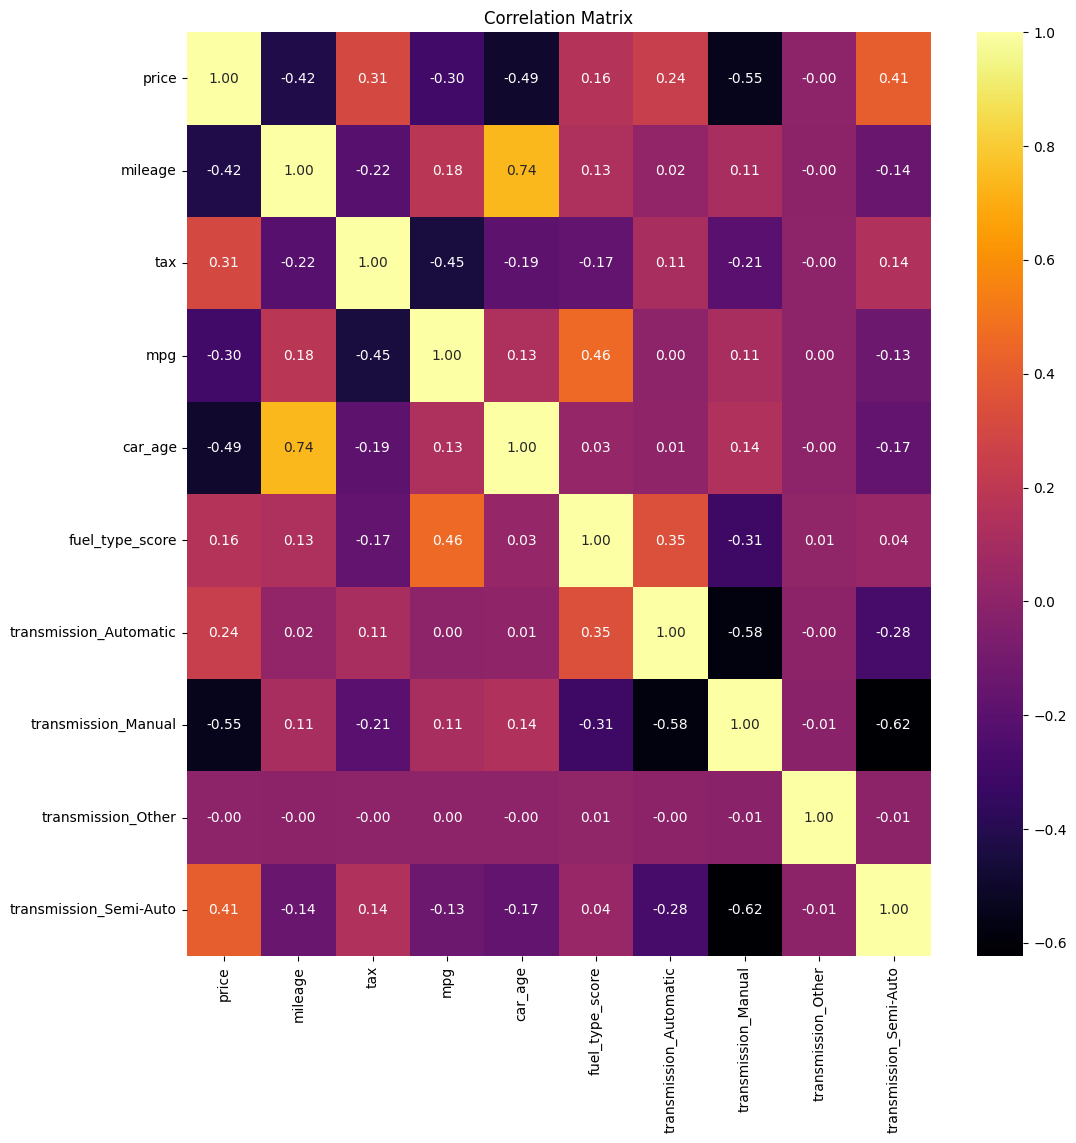

In [30]:
# Calculate the correlation matrix
corr_matrix = cars_multi.corr()

# Plot the heatmap of the correlation matrix
plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, cmap="inferno", annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Simple OLS Regression


In [31]:
# Check simple linear regression R-squared values for each variable against price

response_variables = [
    "mileage",
    "tax",
    "mpg",
    "car_age",
    "fuel_type_score",
    "transmission_Automatic",
    "transmission_Manual",
    "transmission_Other",
    "transmission_Semi-Auto"
]

y = cars_multi["price"]

for response_var in response_variables:
    X = np.array(cars_multi[response_var]).reshape(-1, 1)
    
    model = LinearRegression()
    model.fit(X, y)
    
    r_sq = model.score(X, y)
    
    print(f"R-squared value for price vs {response_var}: {r_sq:.4f}")

R-squared value for price vs mileage: 0.1747
R-squared value for price vs tax: 0.0943
R-squared value for price vs mpg: 0.0873
R-squared value for price vs car_age: 0.2425
R-squared value for price vs fuel_type_score: 0.0255
R-squared value for price vs transmission_Automatic: 0.0590
R-squared value for price vs transmission_Manual: 0.2979
R-squared value for price vs transmission_Other: 0.0000
R-squared value for price vs transmission_Semi-Auto: 0.1690


In [32]:
# Simple OLS regression for each variable against price

simple_ols_variables = [
    "mileage",
    "tax",
    "mpg",
    "car_age",
    "fuel_type_score",
    "transmission_Automatic",
    "transmission_Manual",
    "transmission_Other",
    "transmission_Semi-Auto"
]

y = cars_multi["price"]

for var in simple_ols_variables:
    print("=" * 80)
    print(f"OLS Regression: price against {var}")
    print("=" * 80)
    
    X = sm.add_constant(cars_multi[var])
    
    model = sm.OLS(y, X)
    result = model.fit()
    
    print(result.summary())
    print("Standard error:", result.scale ** 0.5)
    print()

OLS Regression: price against mileage
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.175
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                 2.069e+04
Date:                Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                        16:06:23   Log-Likelihood:            -1.0279e+06
No. Observations:               97712   AIC:                         2.056e+06
Df Residuals:                   97710   BIC:                         2.056e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.

In [33]:
ols_results = []

simple_ols_variables = [
    "mileage",
    "tax",
    "mpg",
    "car_age",
    "fuel_type_score",
    "transmission_Automatic",
    "transmission_Manual",
    "transmission_Other",
    "transmission_Semi-Auto"
]

y = cars_multi["price"]

for var in simple_ols_variables:
    X = sm.add_constant(cars_multi[var])
    model = sm.OLS(y, X)
    result = model.fit()
    
    ols_results.append({
        "Variable": var,
        "R-squared": round(result.rsquared, 3),
        "Adj. R-squared": round(result.rsquared_adj, 3),
        "Coefficient": round(result.params[var], 3),
        "P-value": round(result.pvalues[var], 4),
        "Standard Error": round(result.bse[var], 3),
        "F-statistic": round(result.fvalue, 3),
        "AIC": round(result.aic, 3),
        "BIC": round(result.bic, 3)
    })

ols_summary = pd.DataFrame(ols_results)

ols_summary

,Variable,R-squared,Adj. R-squared,Coefficient,P-value,Standard Error,F-statistic,AIC,BIC
0,mileage,0.17,0.17,-0.20,0.00,0.00,20686.31,2055869.37,2055888.35
1,tax,0.09,0.09,47.82,0.00,0.47,10167.57,2064960.55,2064979.53
2,mpg,0.09,0.09,-180.22,0.00,1.86,9348.84,2065704.96,2065723.94
3,car_age,0.24,0.24,-2293.98,0.00,12.97,31288.20,2047489.50,2047508.48
4,fuel_type_score,0.03,0.03,30508.17,0.00,603.50,2555.53,2072110.63,2072129.61
5,transmission_Automatic,0.06,0.06,5951.00,0.00,76.04,6125.00,2068692.55,2068711.53
6,transmission_Manual,0.30,0.30,-10872.80,0.00,53.41,41449.75,2040080.58,2040099.56
7,transmission_Other,0.00,-0.00,-554.43,0.87,3289.68,0.03,2074633.33,2074652.31
8,transmission_Semi-Auto,0.17,0.17,9667.71,0.00,68.58,19874.14,2056541.96,2056560.94


## Multiple Linear Regression

In [34]:
X = cars_multi.drop(["price", "transmission_Other"], axis=1)
y = cars_multi["price"]

# Add constant to X
X = sm.add_constant(X)

# Initialise the OLS model
model = sm.OLS(y, X)

# Fit the model
result = model.fit()

# Print summary of the regression analysis
print(result.summary())

# Print standard error
print("Standard error:", result.scale ** 0.5)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.542
Model:                            OLS   Adj. R-squared:                  0.542
Method:                 Least Squares   F-statistic:                 1.445e+04
Date:                Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                        16:06:23   Log-Likelihood:            -9.9916e+05
No. Observations:               97712   AIC:                         1.998e+06
Df Residuals:                   97703   BIC:                         1.998e+06
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   3.38

In [35]:
multiple_ols_summary = pd.DataFrame({
    "Variable": result.params.index,
    "Coefficient": result.params.values,
    "P-value": result.pvalues.values,
    "Standard Error": result.bse.values
})

multiple_ols_summary

,Variable,Coefficient,P-value,Standard Error
0,const,33864.36,0.00,2232.13
1,mileage,-0.05,0.00,0.00
2,tax,9.92,0.00,0.39
3,mpg,-153.75,0.00,1.68
4,car_age,-1485.05,0.00,15.13
5,fuel_type_score,38360.57,0.00,524.06
6,transmission_Automatic,6646.05,0.00,2226.89
7,transmission_Manual,-26.04,0.99,2226.87
8,transmission_Semi-Auto,8613.07,0.00,2226.95


## PCA


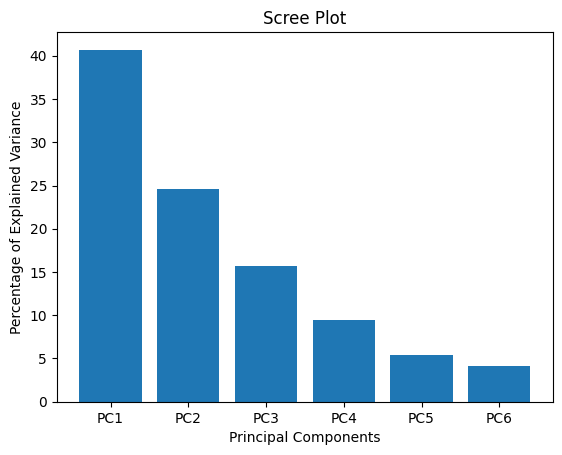

In [36]:
# Select numeric features for PCA
numeric_data = cars[[
    "price",
    "mileage",
    "tax",
    "mpg",
    "car_age",
    "fuel_type_score"
]]

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the data and transform it
scaled_data = scaler.fit_transform(numeric_data)

# Perform PCA
pca = PCA()
pca.fit(scaled_data)

# Explained variance ratio
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)

# Scree plot
labels = ["PC" + str(i) for i in range(1, len(per_var) + 1)]

plt.bar(x=range(1, len(per_var) + 1), height=per_var, tick_label=labels)
plt.ylabel("Percentage of Explained Variance")
plt.xlabel("Principal Components")
plt.title("Scree Plot")
plt.show()

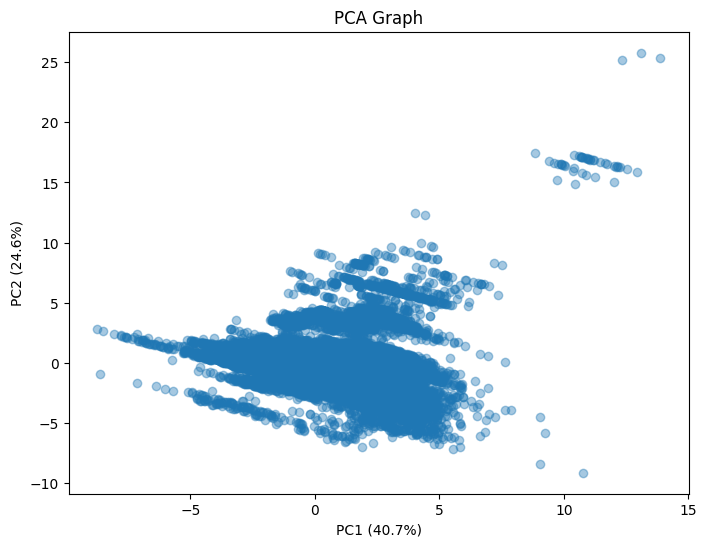

In [37]:
# Transform the scaled data using PCA
pca_data = pca.transform(scaled_data)

# Create a DataFrame for the PCA data
pca_df = pd.DataFrame(pca_data, columns=labels)

# Plot the PCA graph
plt.figure(figsize=(8, 6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.4)
plt.title("PCA Graph")
plt.xlabel(f"PC1 ({per_var[0]}%)")
plt.ylabel(f"PC2 ({per_var[1]}%)")
plt.show()

In [38]:
# PCA loading scores
loading_scores = pd.DataFrame(
    pca.components_,
    columns=numeric_data.columns,
    index=labels
)

loading_scores

,price,mileage,tax,mpg,car_age,fuel_type_score
PC1,-0.45,0.50,-0.37,0.37,0.50,0.17
PC2,0.26,-0.25,-0.31,0.53,-0.34,0.61
PC3,0.43,0.39,0.50,-0.17,0.30,0.54
PC4,-0.51,-0.18,0.71,0.44,-0.09,0.06
PC5,0.51,0.28,0.12,0.59,0.01,-0.54
PC6,0.18,-0.65,-0.01,0.12,0.73,-0.03


In [39]:
# Loading scores for PC1
pc1_loading_scores = pd.Series(
    pca.components_[0],
    index=numeric_data.columns
)

pc1_loading_scores

price             -0.45
mileage            0.50
tax               -0.37
mpg                0.37
car_age            0.50
fuel_type_score    0.17
dtype: float64

In [41]:
# Get the loading scores for PC1
loading_scores_pc1 = pd.Series(
    pca.components_[0],
    index=numeric_data.columns
)

# Sort the loading scores by absolute values
sorted_loading_scores = loading_scores_pc1.abs().sort_values(ascending=False)

# Display variables contributing most to PC1
print("Variables contributing most to PC1:")
print(sorted_loading_scores)

Variables contributing most to PC1:
mileage           0.50
car_age           0.50
price             0.45
tax               0.37
mpg               0.37
fuel_type_score   0.17
dtype: float64


Based on the loading scores for the first principal component, PC1:

- The variables with the highest loading scores are mileage and car_age, both with values of about 0.50. This means they have the strongest influence on PC1. It suggests that PC1 is mainly affected by how old the car is and how much it has been used.
- The variable price also has a strong loading score of -0.45. The negative value means that price moves in the opposite direction to mileage and car_age on PC1. This makes sense because older cars and higher-mileage cars usually have lower prices.
- The variables tax and mpg both have moderate loading scores, with values of about -0.37 and 0.37. This shows that they also contribute to PC1, but not as strongly as mileage, car_age, and price.
- The variable fuel_type_score has the lowest loading score, at about 0.17. This means it has a weaker influence on PC1 compared with the other variables.

## Normalisation and Standardisation

In [43]:
# Select variables for standardisation and normalisation
index_variables = [
    "price",
    "tax",
    "mileage",
    "car_age",
    "mpg",
    "fuel_type_score"
]

scaler_standard = StandardScaler()

cars_standardized = scaler_standard.fit_transform(cars[index_variables])

cars_standardized = pd.DataFrame(
    cars_standardized,
    columns=index_variables
)

# Display the standardized data
print("Standardized data:")
display(cars_standardized.head())

Standardized data:


,price,tax,mileage,car_age,mpg,fuel_type_score
0,-0.94,0.39,-0.55,0.03,0.30,-0.63
1,-0.59,0.39,-0.67,0.03,0.23,-0.63
2,1.14,0.39,-1.03,-0.91,-0.35,0.48
3,-0.43,0.47,0.37,0.03,0.47,0.48
4,-0.89,0.08,-0.18,0.03,-0.06,-0.63


In [44]:
# Initialize the MinMaxScaler for normalisation
scaler_minmax = MinMaxScaler()

# Fit and transform the data for normalisation
cars_normalized = scaler_minmax.fit_transform(cars[index_variables])

# Convert the normalized data back to a DataFrame
cars_normalized = pd.DataFrame(
    cars_normalized,
    columns=index_variables
)

# Display the normalized data
print("\nNormalized data:")
display(cars_normalized.head())


Normalized data:


,price,tax,mileage,car_age,mpg,fuel_type_score
0,0.04,0.25,0.04,0.13,0.13,0.00
1,0.07,0.25,0.03,0.13,0.12,0.00
2,0.17,0.25,0.00,0.09,0.10,0.06
3,0.08,0.26,0.10,0.13,0.13,0.06
4,0.05,0.22,0.06,0.13,0.11,0.00


In [45]:
# Create proper index scores from normalized data

cars["price_score"] = 1 - cars_normalized["price"]
cars["tax_score"] = 1 - cars_normalized["tax"]
cars["mileage_score"] = 1 - cars_normalized["mileage"]
cars["car_age_score"] = 1 - cars_normalized["car_age"]

cars["mpg_score"] = cars_normalized["mpg"]
cars["fuel_type_score_norm"] = cars_normalized["fuel_type_score"]

cars[[
    "price", "price_score",
    "tax", "tax_score",
    "mileage", "mileage_score",
    "car_age", "car_age_score",
    "mpg", "mpg_score",
    "fuel_type_score", "fuel_type_score_norm"
]].head()

,price,price_score,tax,tax_score,mileage,mileage_score,car_age,car_age_score,mpg,mpg_score,fuel_type_score,fuel_type_score_norm
0,7495,0.96,145,0.75,11630,0.96,9,0.87,60.10,0.13,0.00,0.00
1,10989,0.93,145,0.75,9200,0.97,9,0.87,58.90,0.12,0.00,0.00
2,27990,0.83,145,0.75,1614,1.00,7,0.91,49.60,0.10,0.06,0.06
3,12495,0.92,150,0.74,30960,0.90,9,0.87,62.80,0.13,0.06,0.06
4,7999,0.95,125,0.78,19353,0.94,9,0.87,54.30,0.11,0.00,0.00


In [ ]:
# Select relevant columns for clustering
cluster_columns = [
    "price_score",
    "tax_score",
    "mileage_score",
    "car_age_score",
    "mpg_score",
    "fuel_type_score_norm"
]

cluster_data = cars[cluster_columns].copy()

cluster_data.head()

## Cluster Analysis

### 1. Hierarchical Clustering

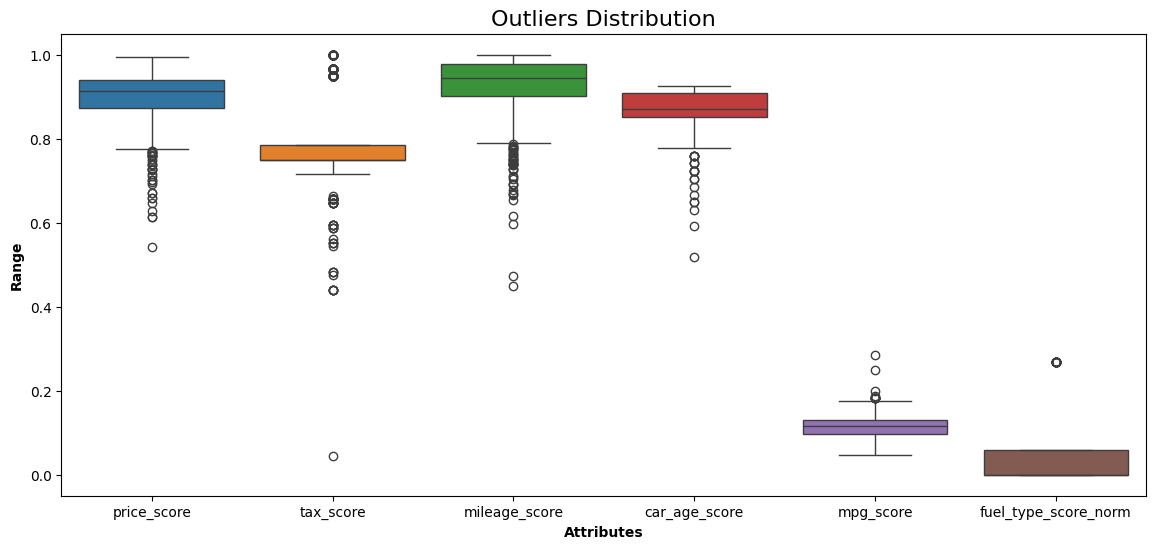

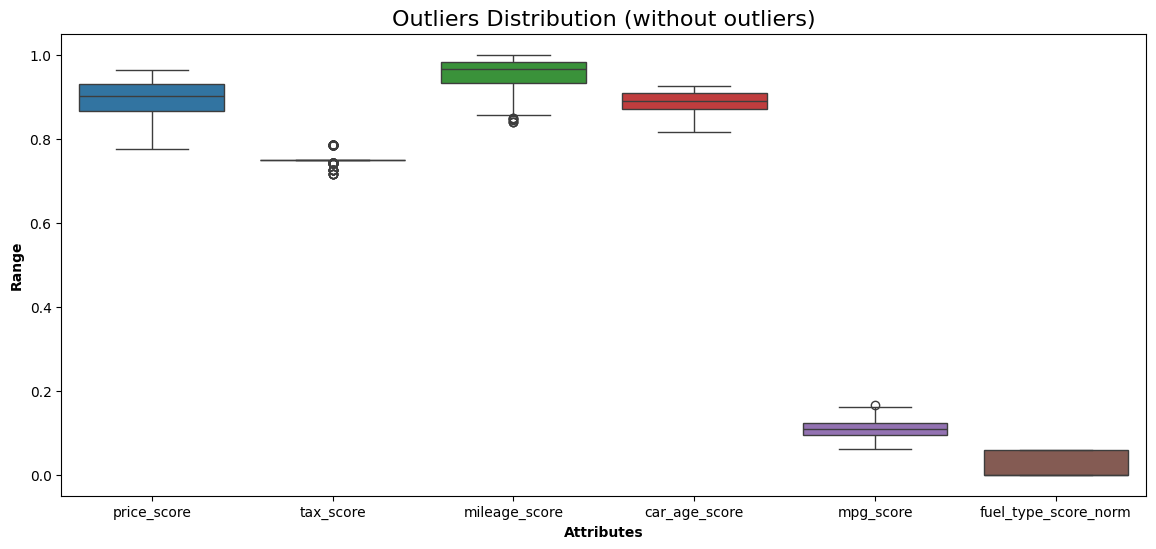

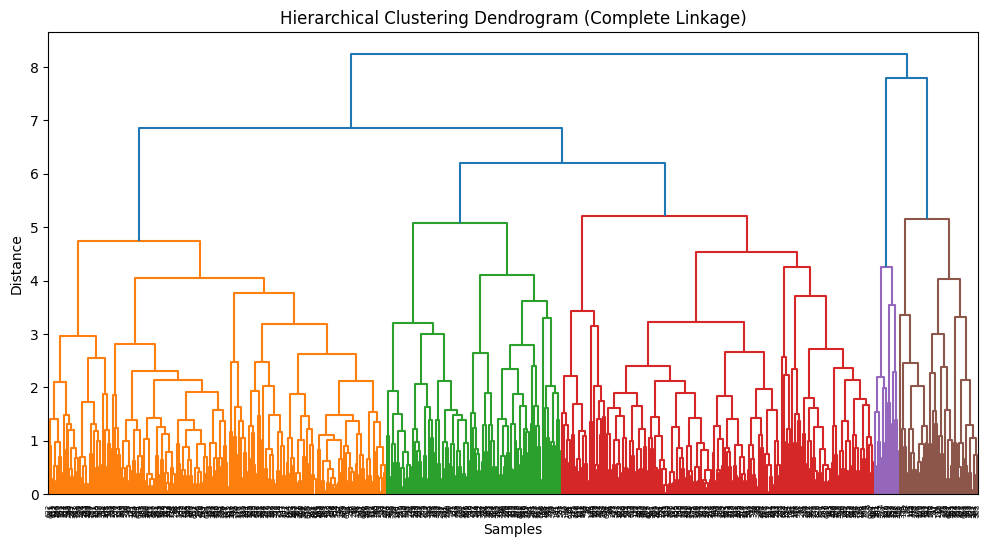

Original cluster sample shape: (1000, 6)
Cluster data shape after removing outliers: (633, 6)


In [46]:
# Hierarchical Clustering using a sample of 1000 cars

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler

# Select relevant columns for clustering
cluster_columns = [
    "price_score",
    "tax_score",
    "mileage_score",
    "car_age_score",
    "mpg_score",
    "fuel_type_score_norm"
]

cluster_data = cars[cluster_columns].copy()

# Drop any rows with missing values
cluster_data = cluster_data.dropna()

# Select only 1000 samples because hierarchical clustering is slow with large datasets
cluster_sample = cluster_data.sample(n=1000, random_state=42)

# Show boxplot before removing outliers
plt.rcParams["figure.figsize"] = [14, 6]
sns.boxplot(data=cluster_sample, orient="v")
plt.title("Outliers Distribution", fontsize=16)
plt.ylabel("Range", fontweight="bold")
plt.xlabel("Attributes", fontweight="bold")
plt.show()

# Remove outliers using IQR method
cluster_no_outliers = cluster_sample.copy()

for col in list(cluster_no_outliers.columns):
    Q1 = cluster_no_outliers[col].quantile(0.25)
    Q3 = cluster_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    cluster_no_outliers = cluster_no_outliers[
        (cluster_no_outliers[col] >= lower_bound) &
        (cluster_no_outliers[col] <= upper_bound)
    ]

# Show boxplot after removing outliers
plt.rcParams["figure.figsize"] = [14, 6]
sns.boxplot(data=cluster_no_outliers, orient="v")
plt.title("Outliers Distribution (without outliers)", fontsize=16)
plt.ylabel("Range", fontweight="bold")
plt.xlabel("Attributes", fontweight="bold")
plt.show()

# Standardize the data
data_scaler = StandardScaler()
scaled_cluster_data = data_scaler.fit_transform(cluster_no_outliers)

# Perform hierarchical clustering with complete linkage
complete_clustering = linkage(
    scaled_cluster_data,
    method="complete",
    metric="euclidean"
)

# Plot dendrogram for complete linkage
plt.figure(figsize=(12, 6))
dendrogram(complete_clustering)
plt.title("Hierarchical Clustering Dendrogram (Complete Linkage)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# Check final shape after outlier removal
print("Original cluster sample shape:", cluster_sample.shape)
print("Cluster data shape after removing outliers:", cluster_no_outliers.shape)

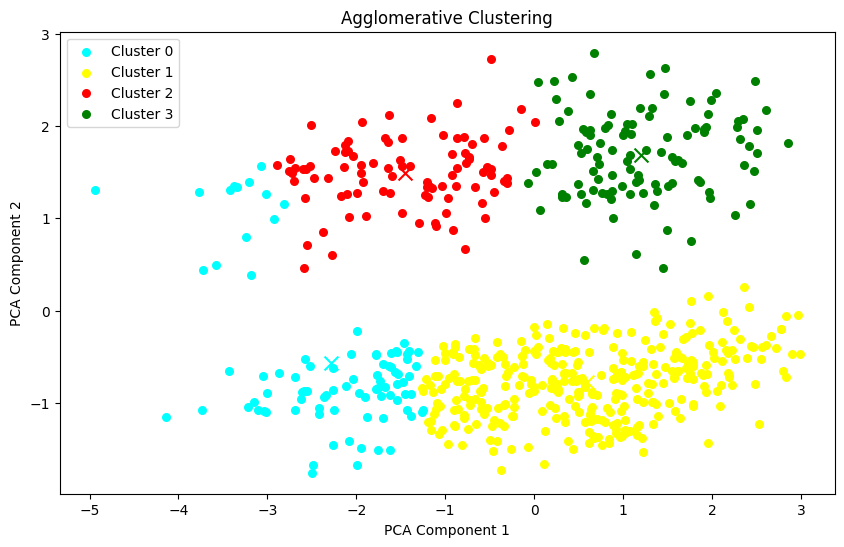

In [48]:
# Perform PCA for visualisation
pca = PCA(n_components=2)
cluster_data_pca = pca.fit_transform(scaled_cluster_data)

# Perform hierarchical/agglomerative clustering
hc = AgglomerativeClustering(
    n_clusters=4,
    linkage="complete",
    metric="euclidean"
)

y_hc = hc.fit_predict(cluster_data_pca)

# Plot the data points with cluster colours
colors = ["cyan", "yellow", "red", "green"]

plt.figure(figsize=(10, 6))

for cluster_label, color in zip(range(4), colors):
    plt.scatter(
        cluster_data_pca[y_hc == cluster_label, 0],
        cluster_data_pca[y_hc == cluster_label, 1],
        s=30,
        c=color,
        label=f"Cluster {cluster_label}"
    )

# Plot the cluster centres
for cluster_label, color in zip(range(4), colors):
    cluster_center = np.mean(cluster_data_pca[y_hc == cluster_label], axis=0)
    plt.scatter(
        cluster_center[0],
        cluster_center[1],
        s=100,
        c=color,
        marker="x"
    )

# Customise the plot
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Agglomerative Clustering")
plt.legend()
plt.show()

### KMeans Clustering

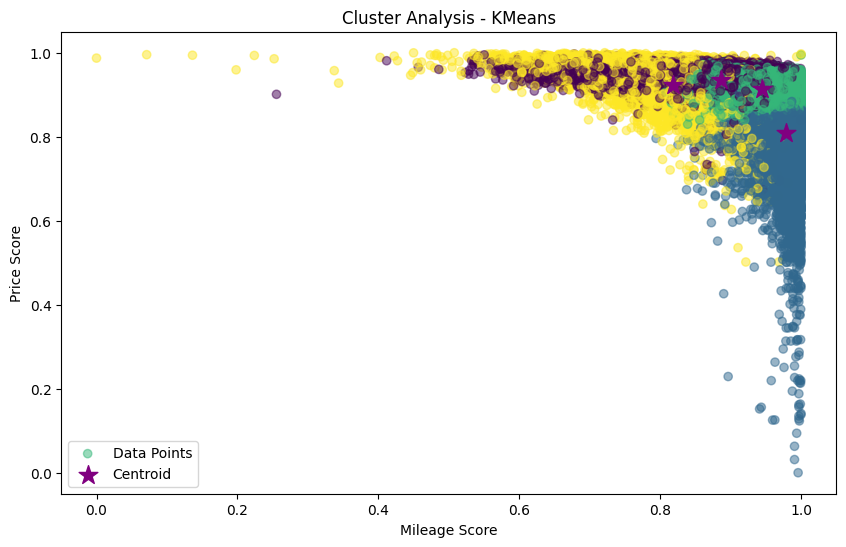

In [50]:
from sklearn.cluster import KMeans

# Select relevant columns
X = cars[cluster_columns].copy()

# Drop any rows with missing values
X = X.dropna()

# Scale the data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Perform KMeans clustering
km = KMeans(n_clusters=4, n_init="auto", random_state=42)
y_predicted = km.fit_predict(X_scaled)

# Assign cluster labels to a copy of the data
kmeans_data = X.copy()
kmeans_data["cluster"] = y_predicted

# Plot clusters using mileage_score and price_score
plt.figure(figsize=(10, 6))
plt.scatter(
    kmeans_data["mileage_score"],
    kmeans_data["price_score"],
    c=kmeans_data["cluster"],
    cmap="viridis",
    label="Data Points",
    alpha=0.5
)

# Plot centroids
plt.scatter(
    km.cluster_centers_[:, cluster_columns.index("mileage_score")],
    km.cluster_centers_[:, cluster_columns.index("price_score")],
    color="purple",
    marker="*",
    s=200,
    label="Centroid"
)

plt.xlabel("Mileage Score")
plt.ylabel("Price Score")
plt.title("Cluster Analysis - KMeans")
plt.legend()
plt.show()

## Weighting and Aggregate

In [53]:
# Create sub-indices

cars["affordability_score"] = (
    cars["price_score"] * 0.70 +
    cars["tax_score"] * 0.30
)

cars["condition_age_score"] = (
    cars["mileage_score"] * 0.50 +
    cars["car_age_score"] * 0.50
)

cars["efficiency_score"] = (
    cars["mpg_score"] * 0.70 +
    cars["fuel_type_score_norm"] * 0.30
)

cars[[
    "price_score",
    "tax_score",
    "affordability_score",
    "mileage_score",
    "car_age_score",
    "condition_age_score",
    "mpg_score",
    "fuel_type_score_norm",
    "efficiency_score"
]].head()

,price_score,tax_score,affordability_score,mileage_score,car_age_score,condition_age_score,mpg_score,fuel_type_score_norm,efficiency_score
0,0.96,0.75,0.89,0.96,0.87,0.92,0.13,0.00,0.09
1,0.93,0.75,0.88,0.97,0.87,0.92,0.12,0.00,0.09
2,0.83,0.75,0.80,1.00,0.91,0.95,0.10,0.06,0.09
3,0.92,0.74,0.87,0.90,0.87,0.89,0.13,0.06,0.11
4,0.95,0.78,0.90,0.94,0.87,0.91,0.11,0.00,0.08


In [54]:
# Create Car Value-for-Money Index

cars["car_value_index"] = (
    cars["affordability_score"] * 0.40 +
    cars["condition_age_score"] * 0.35 +
    cars["efficiency_score"] * 0.25
)

cars[[
    "manufacturer",
    "model",
    "year",
    "price",
    "mileage",
    "fuel_type",
    "transmission",
    "affordability_score",
    "condition_age_score",
    "efficiency_score",
    "car_value_index"
]].head()

,manufacturer,model,year,price,mileage,fuel_type,transmission,affordability_score,condition_age_score,efficiency_score,car_value_index
0,Hyundai,I10,2017,7495,11630,Petrol,Manual,0.89,0.92,0.09,0.70
1,Volkswagen,Polo,2017,10989,9200,Petrol,Manual,0.88,0.92,0.09,0.70
2,BMW,2 Series,2019,27990,1614,Diesel,Semi-Auto,0.80,0.95,0.09,0.68
3,Skoda,Yeti Outdoor,2017,12495,30960,Diesel,Manual,0.87,0.89,0.11,0.69
4,Ford,Fiesta,2017,7999,19353,Petrol,Manual,0.90,0.91,0.08,0.70


In [57]:
# Top 20 cars by final index score

cars_ranked = cars.sort_values(
    by="car_value_index",
    ascending=False
).copy()

cars_ranked[[
    "manufacturer",
    "model",
    "year",
    "price",
    "mileage",
    "fuel_type",
    "transmission",
    "affordability_score",
    "condition_age_score",
    "efficiency_score",
    "car_value_index"
]].head(20)

,manufacturer,model,year,price,mileage,fuel_type,transmission,affordability_score,condition_age_score,efficiency_score,car_value_index
76852,BMW,i3,2016,18999,9990,Electric,Automatic,0.92,0.91,1.00,0.94
72119,BMW,i3,2015,17400,29465,Electric,Automatic,0.93,0.87,1.00,0.93
78929,BMW,i3,2017,18999,20321,Electric,Automatic,0.85,0.90,1.00,0.91
14380,BMW,i3,2016,19490,8421,Hybrid,Automatic,0.92,0.91,0.78,0.88
25693,BMW,i3,2015,17481,9886,Hybrid,Automatic,0.93,0.90,0.78,0.88
56560,BMW,i3,2017,21898,10839,Hybrid,Automatic,0.91,0.92,0.78,0.88
10959,BMW,i3,2017,19000,23983,Hybrid,Automatic,0.92,0.90,0.78,0.88
64276,BMW,i3,2016,19850,19995,Hybrid,Automatic,0.91,0.89,0.78,0.87
59589,BMW,i3,2016,19875,20013,Hybrid,Automatic,0.91,0.89,0.78,0.87
39820,BMW,i3,2017,21444,22063,Hybrid,Automatic,0.91,0.90,0.78,0.87


In [56]:
# Save final indexed dataset

cars_ranked.to_csv("../data/cleaned/cars_with_value_index.csv", index=False)

print("Final indexed dataset saved.")

Final indexed dataset saved.


## Visualisation

In [58]:
# Visualisation of Results

import matplotlib.pyplot as plt

# Create ranked dataset
cars_ranked = cars.sort_values(by="car_value_index", ascending=False).copy()

# Create readable car name
cars_ranked["car_name"] = (
    cars_ranked["manufacturer"].astype(str) + " " +
    cars_ranked["model"].astype(str) + " (" +
    cars_ranked["year"].astype(str) + ")"
)

# Create image folder if needed
from pathlib import Path
Path("../images").mkdir(parents=True, exist_ok=True)

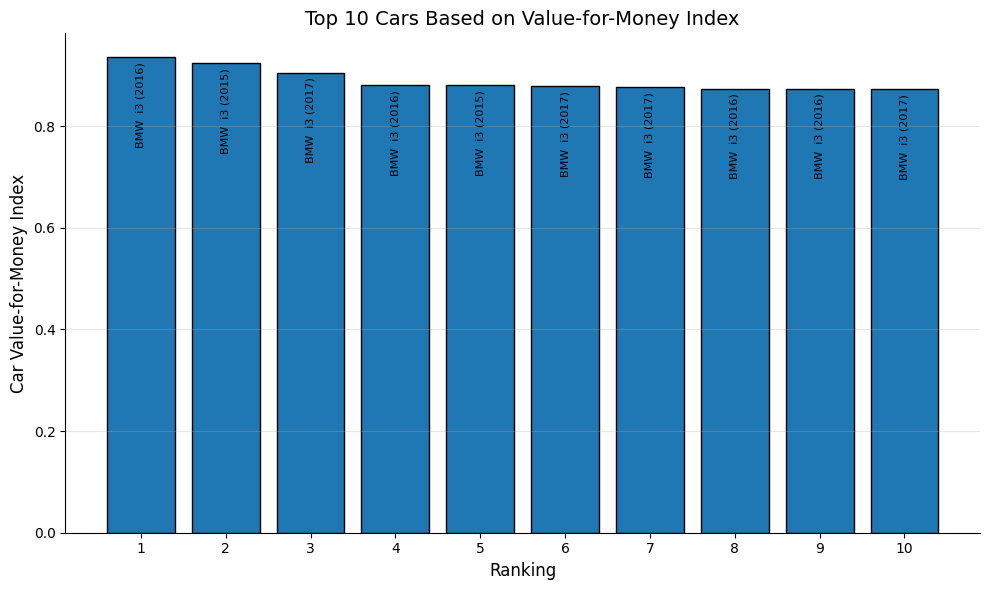

In [63]:
# Prepare data for visualisation
top_10_cars = cars_ranked.head(10).copy()

# Sort by descending index
top_10_cars = top_10_cars.sort_values(by="car_value_index", ascending=False)


top_10_cars["car_label"] = (
    top_10_cars["manufacturer"].astype(str) + " " +
    top_10_cars["model"].astype(str) + " (" +
    top_10_cars["year"].astype(str) + ")"
)

car_labels = top_10_cars["car_label"].tolist()
value_indices = top_10_cars["car_value_index"].tolist()

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(
    range(1, len(car_labels) + 1),
    value_indices,
    edgecolor="black"
)


for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 0.01,
        car_labels[i],
        ha="center",
        va="top",
        rotation=90,
        fontsize=8
    )

plt.xlabel("Ranking", fontsize=12)
plt.ylabel("Car Value-for-Money Index", fontsize=12)
plt.title("Top 10 Cars Based on Value-for-Money Index", fontsize=14)
plt.xticks(range(1, len(car_labels) + 1), fontsize=10)
plt.yticks(fontsize=10)

# Tufte-style cleanup
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../images/top_10_value_cars.png", dpi=300, bbox_inches="tight")
plt.show()

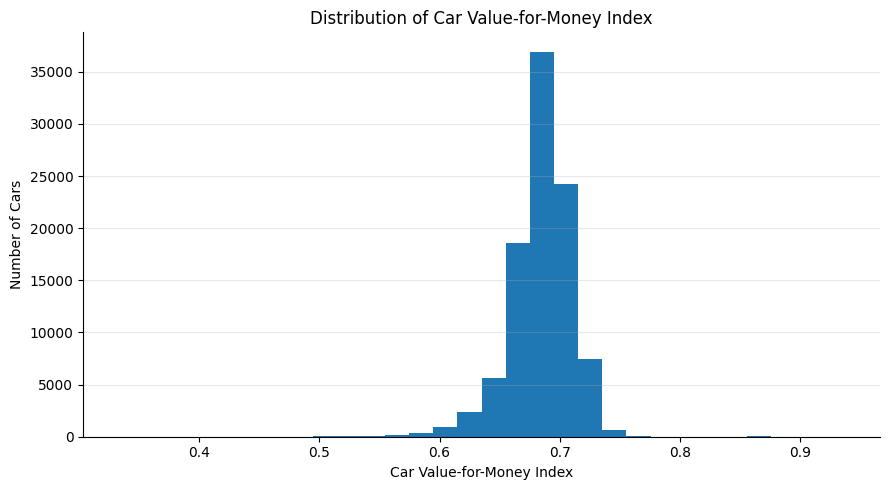

In [60]:
plt.figure(figsize=(9, 5))
plt.hist(cars["car_value_index"], bins=30)
plt.xlabel("Car Value-for-Money Index")
plt.ylabel("Number of Cars")
plt.title("Distribution of Car Value-for-Money Index")

plt.grid(axis="y", alpha=0.3)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../images/value_index_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

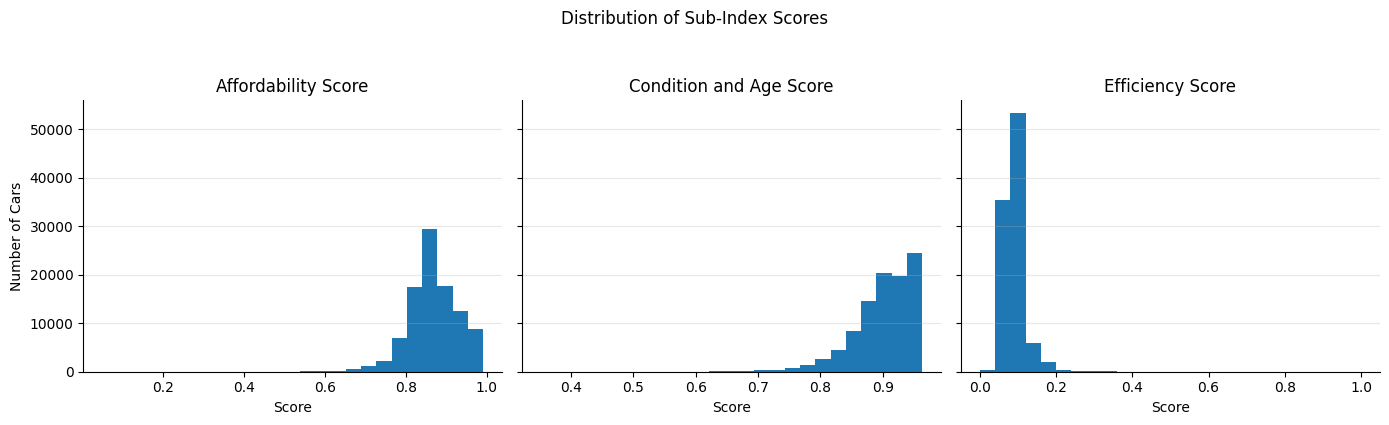

In [61]:
sub_index_columns = [
    "affordability_score",
    "condition_age_score",
    "efficiency_score"
]

sub_index_titles = [
    "Affordability Score",
    "Condition and Age Score",
    "Efficiency Score"
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, col, title in zip(axes, sub_index_columns, sub_index_titles):
    ax.hist(cars[col], bins=25)
    ax.set_title(title)
    ax.set_xlabel("Score")
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Number of Cars")

fig.suptitle("Distribution of Sub-Index Scores", y=1.05)
plt.tight_layout()
plt.savefig("../images/subindex_distribution_small_multiples.png", dpi=300, bbox_inches="tight")
plt.show()

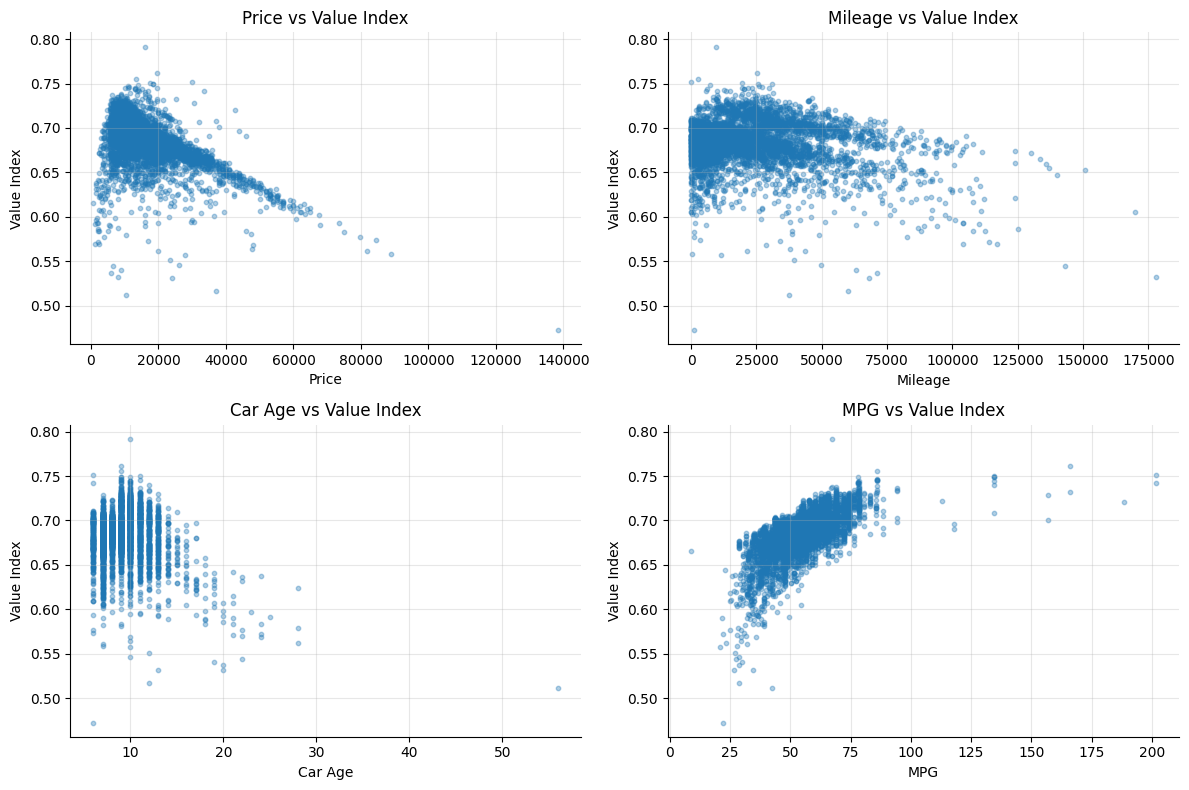

In [62]:
plot_variables = [
    ("price", "Price"),
    ("mileage", "Mileage"),
    ("car_age", "Car Age"),
    ("mpg", "MPG")
]

# Use a sample to keep the plots readable
plot_sample = cars.sample(5000, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (col, title) in zip(axes.flatten(), plot_variables):
    ax.scatter(plot_sample[col], plot_sample["car_value_index"], alpha=0.35, s=10)
    ax.set_xlabel(title)
    ax.set_ylabel("Value Index")
    ax.set_title(f"{title} vs Value Index")
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../images/key_variables_vs_value_index_small_multiples.png", dpi=300, bbox_inches="tight")
plt.show()

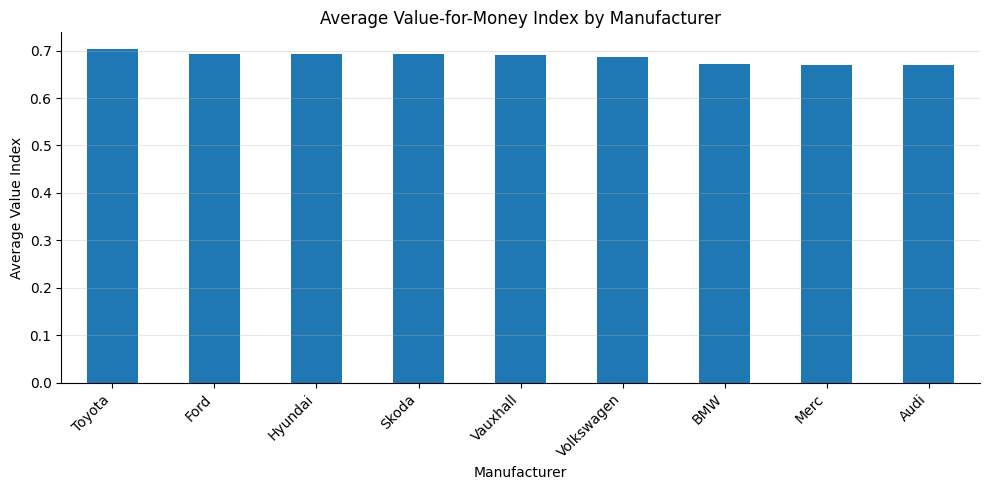

In [64]:
manufacturer_value = (
    cars.groupby("manufacturer")["car_value_index"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
manufacturer_value.plot(kind="bar")
plt.xlabel("Manufacturer")
plt.ylabel("Average Value Index")
plt.title("Average Value-for-Money Index by Manufacturer")
plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../images/average_value_by_manufacturer.png", dpi=300, bbox_inches="tight")
plt.show()